In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning Modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, recall_score, roc_auc_score, 
                             classification_report, confusion_matrix, roc_curve)

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight') # Professional plot style

In [2]:
# Load dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nData Types and Missing Values:")
print(df.info())

# Drop unique identifier
df.drop('customerID', axis=1, inplace=True)

Dataset Shape: (7043, 21)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null

In [3]:
# Handling 'TotalCharges' column string-to-float conversion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for Null values created by coercion
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

# Median Imputation (MSc Level practice)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Verify cleaning
print("Missing values after imputation:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11
Missing values after imputation: 0


In [4]:
# Initializing LabelEncoder
le = LabelEncoder()

# List of binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'Churn']

# Apply Label Encoding
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Applying One-Hot Encoding for multi-category columns
df = pd.get_dummies(df)

# Ensuring all columns are numeric for the models
df = df.astype(float)

print("Final encoded feature count:", df.shape[1])

Final encoded feature count: 41


In [5]:
# Defining Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Stratified Splitting to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling Features (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5634, 40)
Testing set size: (1409, 40)


In [6]:
# Dictionary to hold models with tuned parameters
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, C=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.05, eval_metric='logloss', random_state=42)
}

# Dictionary to store performance
performance_metrics = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    performance_metrics.append({
        "Model": name,
        "Accuracy": acc,
        "Recall": rec,
        "ROC-AUC": auc
    })

Training Logistic Regression...
Training Random Forest...
Training XGBoost...



--- Model Performance Summary ---
                 Model  Accuracy    Recall   ROC-AUC
0  Logistic Regression  0.806955  0.566845  0.841595
2              XGBoost  0.794890  0.516043  0.840355
1        Random Forest  0.795600  0.513369  0.837039


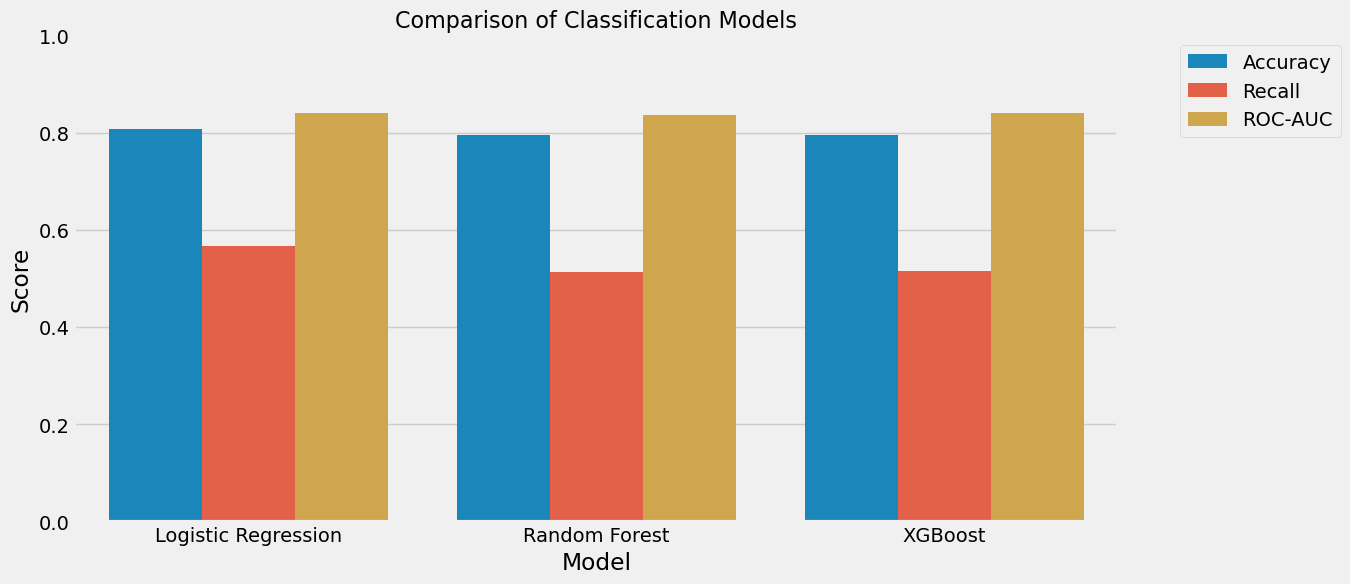

In [7]:
# Create Comparison DataFrame
comparison_df = pd.DataFrame(performance_metrics)

print("\n--- Model Performance Summary ---")
print(comparison_df.sort_values(by='ROC-AUC', ascending=False))

# Visualization
plt.figure(figsize=(12, 6))
melted_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_df)
plt.title('Comparison of Classification Models', fontsize=16)
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

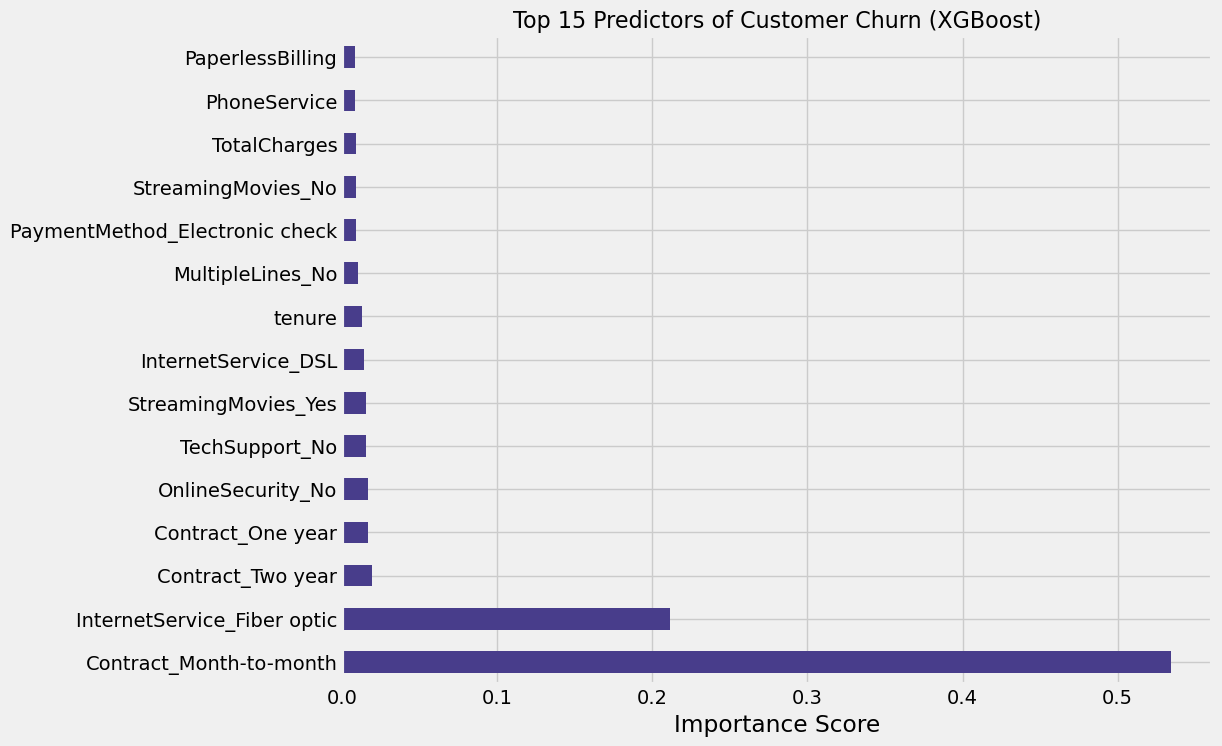

In [8]:
# Feature Importance from the Best Model (XGBoost)
best_model = models["XGBoost"]
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 8))
feat_importances.nlargest(15).plot(kind='barh', color='darkslateblue')
plt.title('Top 15 Predictors of Customer Churn (XGBoost)', fontsize=16)
plt.xlabel('Importance Score')
plt.show()